In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
X = np.array([
    [1.0, 1.0], [1.5, 1.2], [2.0, 1.8], [2.2, 2.0],
    [2.5, 2.3], [3.0, 2.8], [3.2, 3.0], [3.5, 3.2],
    [4.0, 3.8], [4.5, 4.0], [5.0, 4.5], [5.5, 5.0]
])

y = np.array([0,0,0,0,0,0,1,1,1,1,1,1])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 2)
y shape: (12,)


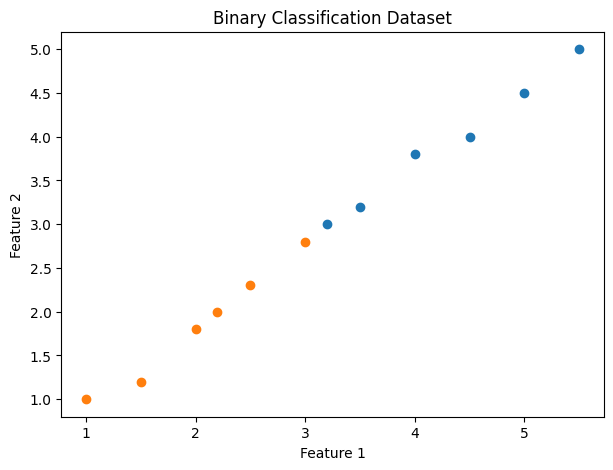

In [3]:
plt.figure(figsize=(7,5))
plt.plot(X[y==1,0], X[y==1,1], 'o',label='Class 1')
plt.plot(X[y==0,0],X[y==0,1],'o',label='Class 0')#my answer
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.show()

In [4]:
def sigmoid(z):
   
    sigz=1/(1+np.exp(-z))
    return sigz

In [5]:
test_values = np.array([-10, -2, 0, 2, 10])
print(sigmoid(test_values))



[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


In [6]:
def compute_z(X, w, b):
    
    return np.dot(X,w)+b
    

In [7]:
w = np.zeros(X.shape[1])
b = 0.0

z = compute_z(X, w, b)

print("z:", z)
print("z shape:", z.shape)

z: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
z shape: (12,)


In [8]:
def predict_probability(X, w, b):
   
    return sigmoid(np.dot(X,w)+b)

In [9]:
probabilities = predict_probability(X, w, b)
print(probabilities)

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [10]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    pred = predict_probability(X, w, b)
    cost = -(np.sum(y*np.log(pred)+(1-y)*np.log(1-pred)))/m


    return cost

In [11]:
initial_cost = compute_cost(X, y, w, b)
print("Initial cost:", initial_cost)


Initial cost: 0.6931471805599453


In [12]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]
    pred=predict_probability(X,w,b)
    dw=np.dot(X.T,pred-y)/m
    db=np.sum(pred-y)/m

    

    return dw, db

In [13]:
dw, db = compute_gradients(X, y, w, b)

print("dw:", dw)
print("dw shape:", dw.shape)
print("db:", db)

dw: [-0.5625     -0.51666667]
dw shape: (2,)
db: 0.0


In [14]:
def gradient_descent_step(X, y, w, b, learning_rate):
    
    dw, db = compute_gradients(X, y, w, b)
    w=w-learning_rate*dw
    b=b-learning_rate*db

    return w, b

In [15]:
def train_logistic_regression(X, y, learning_rate=0.1, num_iterations=1000):

    w=np.zeros(X.shape[1])
    b=0.0

    cost_history=[]

    for i in range(num_iterations):

        z=X.dot(w) + b
        y_hat=sigmoid(z)
        m=X.shape[0]
        cost=-(1/m) * np.sum(y*np.log(y_hat) +(1-y)*np.log(1-y_hat))
        dw=(1/m) * X.T.dot(y_hat - y)
        db=(1/m) * np.sum(y_hat - y)
        w=w - learning_rate * dw
        b=b - learning_rate * db
        cost_history.append(cost)

    return w, b, cost_history

In [16]:
learning_rate = 0.1
num_iterations = 1000

w, b, cost_history = train_logistic_regression(
    X, y, learning_rate, num_iterations
)

print("Final weights:", w)
print("Final bias:", b)
print("Final cost:", cost_history[-1])

Final weights: [0.93237099 1.04970645]
Final bias: -5.656246822064308
Final cost: 0.20888817201258197


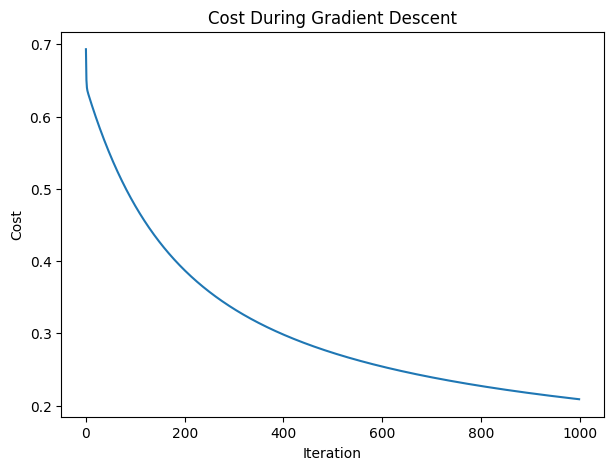

In [17]:
plt.figure(figsize=(7,5))


plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Gradient Descent")
plt.show()

In [18]:
def predict(X, w, b, threshold=0.5):
   z = X.dot(w) + b
   probabilities = sigmoid(z)
   predictions = (probabilities >= threshold).astype(int)
   return predictions

In [19]:
y_pred = predict(X, w, b)

print("Predictions:", y_pred)
print("Actual:     ", y)

Predictions: [0 0 0 0 0 1 1 1 1 1 1 1]
Actual:      [0 0 0 0 0 0 1 1 1 1 1 1]


In [20]:
def accuracy(y_true, y_pred):
  
    accuracy=np.mean(y_pred==y_true)*100
    return accuracy

In [21]:
print("Accuracy:", accuracy(y, y_pred))

Accuracy: 91.66666666666666


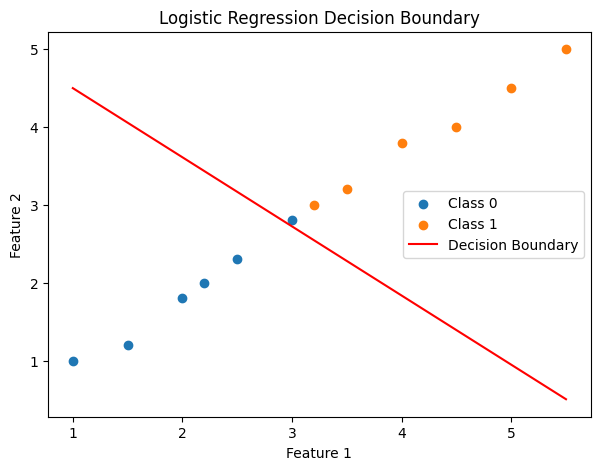

In [22]:
plt.figure(figsize=(7,5))


plt.scatter(X[y==0,0],X[y==0,1],label="Class 0")
plt.scatter(X[y==1,0],X[y==1,1],label="Class 1")
x1=np.linspace(X[:,0].min(),X[:,0].max(),100)
x2=-(w[0]*x1+b)/w[1]
plt.plot(x1,x2,color="red",label="Decision Boundary")



plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

In [23]:
learning_rates = [0.001, 0.1, 1.0]



for lr in learning_rates:

    w_lr,b_lr,cost_lr=train_logistic_regression(X,y,learning_rate=lr,num_iterations=1000)
    

    pred_lr=predict(X,w_lr,b_lr)

    acc_lr=accuracy(y,pred_lr)

    print("Learning Rate =",lr)
    print("Final Cost =",cost_lr[-1])
    print("Accuracy =",acc_lr)
    print()
    
 #0.1 appears as a good learning rate because it neither overfits nor underfits the data   

Learning Rate = 0.001
Final Cost = 0.6199321449891076
Accuracy = 50.0

Learning Rate = 0.1
Final Cost = 0.20888817201258197
Accuracy = 91.66666666666666

Learning Rate = 1.0
Final Cost = 0.10010793569421689
Accuracy = 100.0



In [24]:
thresholds = [0.3, 0.5, 0.7]


for t in thresholds:
    
    pred_t=predict(X,w,b,threshold=t)

    acc_t=accuracy(y,pred_t)

    print("Threshold =",t)
    print("Predictions =",pred_t)
    print("Accuracy =",acc_t)
    print()

Threshold = 0.3
Predictions = [0 0 0 0 0 1 1 1 1 1 1 1]
Accuracy = 91.66666666666666

Threshold = 0.5
Predictions = [0 0 0 0 0 1 1 1 1 1 1 1]
Accuracy = 91.66666666666666

Threshold = 0.7
Predictions = [0 0 0 0 0 0 0 1 1 1 1 1]
Accuracy = 91.66666666666666

